In [1]:
#導入需要的依賴包
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')



# #統計預測圖
seaborn.relplot() 是一個非常好用的繪圖指令, 可以一次把數個變數的關係呈現在一張圖表上.

`load_dataset` looks for online csv files on https://github.com/mwaskom/seaborn-data. Here's the docstring:<br>

Load a dataset from the online repository (requires internet).<br>

>Parameters

>name : str Name of the dataset (name.csv on https://github.com/mwaskom/seaborn-data). You can obtain list of available datasets using func:get_dataset_names<br>
kws : dict, optional Passed to pandas.read_csv


In [2]:
#加載sns內置數據集 
tips = sns.load_dataset("tips")

sns.set(color_codes=True)

tips.head(3)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3



內建數據集-tips數據集 
> 關於數據集，total_bill是消費總金額，tip是小費，size指用餐人數。

In [6]:
NBA = sns.load_dataset('data/NBA_season1718_salary.csv')

ValueError: 'data/NBA_season1718_salary.csv' is not one of the example datasets.

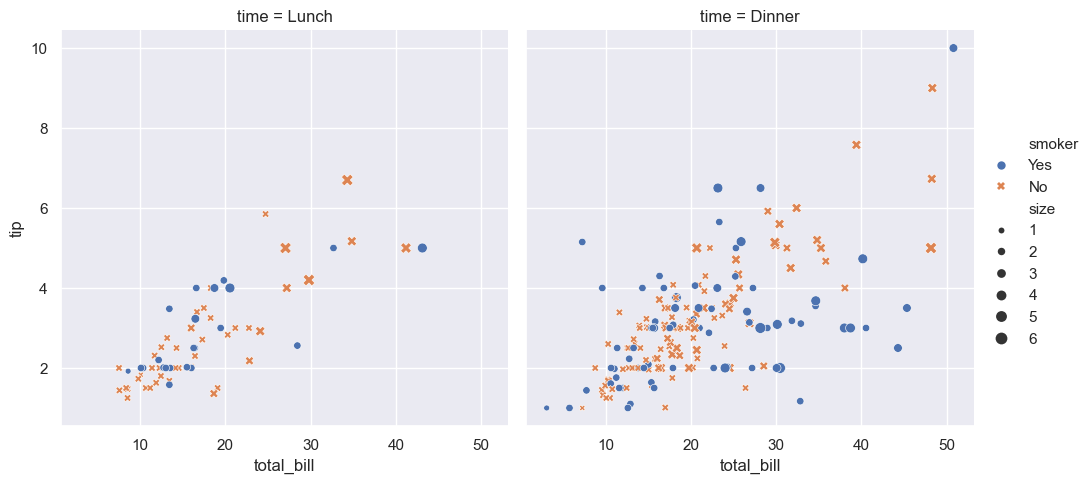

In [4]:
sns.relplot(x='total_bill', y='tip', col='time', hue='smoker', style='smoker', size='size', data=tips)

# #單變量分析繪圖（直方圖、條形圖）
> Dataset: NBA_season1718_salary.csv<br>
ref:https://www.kaggle.com/koki25ando/salary

In [8]:
data = pd.read_csv('data/NBA_season1718_salary.csv') 
data

,Unnamed: 0,Player,Tm,season17_18
0,1,Stephen Curry,GSW,34682550.0
1,2,LeBron James,CLE,33285709.0
2,3,Paul Millsap,DEN,31269231.0
3,4,Gordon Hayward,BOS,29727900.0
4,5,Blake Griffin,DET,29512900.0
...,...,...,...,...
568,569,Quinn Cook,NOP,25000.0
569,570,Chris Johnson,HOU,25000.0
570,571,Beno Udrih,DET,25000.0
571,572,Joel Bolomboy,MIL,22248.0


In [9]:
#對讀進來的數據按薪資降序排序並取前10條數據
salary_top10 = (data.sort_values("season17_18", ascending=False)).head(10)

salary_top10

,Unnamed: 0,Player,Tm,season17_18
0,1,Stephen Curry,GSW,34682550.0
1,2,LeBron James,CLE,33285709.0
2,3,Paul Millsap,DEN,31269231.0
3,4,Gordon Hayward,BOS,29727900.0
4,5,Blake Griffin,DET,29512900.0
5,6,Kyle Lowry,TOR,28703704.0
6,7,Russell Westbrook,OKC,28530608.0
7,8,Mike Conley,MEM,28530608.0
8,9,James Harden,HOU,28299399.0
9,10,DeMar DeRozan,TOR,27739975.0


In [10]:
#取出球員列數據，作為條形圖橫坐標

player = salary_top10['Player']

#取出球員薪資列，作為條形圖縱坐標

season_salary = salary_top10['season17_18']

<AxesSubplot:xlabel='Player', ylabel='season17_18'>

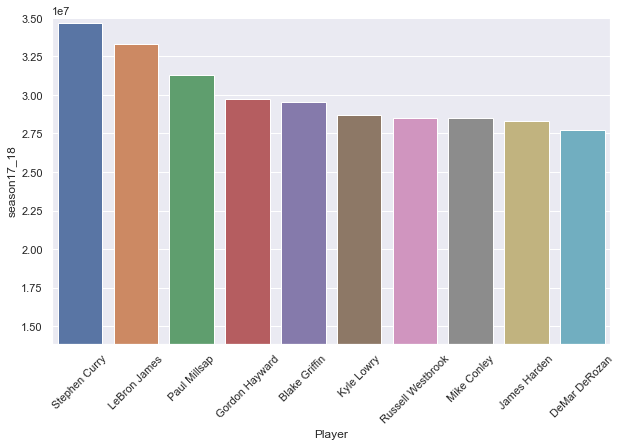

In [7]:


#ci參數表示允許的誤差範圍（控制誤差棒的百分比，在0-100之間）



## Result

從條形圖中不難看出，勇士隊的當家球星curry資最高，將近達到3500萬美元，位居第二的是勒布朗詹姆斯，也是在3300萬美元以上。上面的條形圖是按球員作為橫坐標，下面我們按球隊匯總，看看哪個球隊的薪資總額最高。

# 練習 - 彙總球隊薪資繪製成直方圖
按球隊匯總，看看哪個球隊的薪資總額最高。

<Axes: xlabel='Player', ylabel='season17_18'>

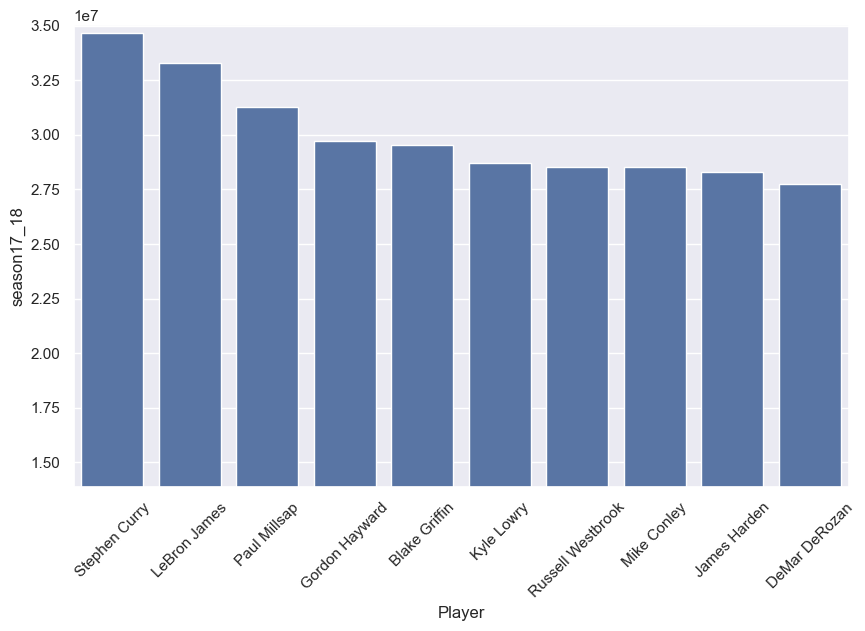

In [11]:
plt.figure(figsize=(10, 6))

 

# 將 X 軸標籤旋轉 45 度，避免球員名字太長重疊在一起

plt.xticks(rotation=45)

 

# 設定 Y 軸範圍，下限設為最小薪資的一半，上限設為最大薪資的 1.01 倍

plt.ylim(season_salary.min() * 0.5, season_salary.max() * 1.01)

 

# ci 參數表示允許的誤差範圍（控制誤差棒的百分比，在 0-100 之間）

sns.barplot(x=player, y=season_salary, data=salary_top10, ci=68)

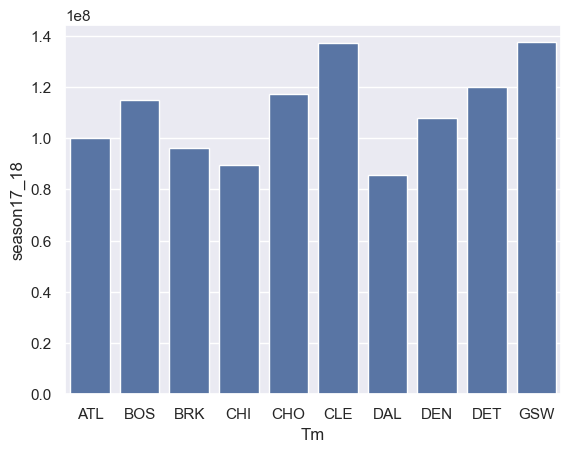

In [16]:
#先將資料集用groupby根據球隊分別匯總
salary_by_team = data.groupby(by='Tm').sum().reset_index()

 

# 根據 17-18 賽季總薪資進行降序排序 salary_by_team = salary_by_team.sort_values(by='season17_18', ascending=False)

 

# 取出前 10 筆數據

tm_top10 = salary_by_team[:10]

# 定義橫座標為球隊名稱，縱座標為薪資總額

tm = tm_top10['Tm'] 
salary_sum = tm_top10['season17_18']

# 繪製長條圖

sns.barplot(x=tm, y=salary_sum, data=tm_top10)

# 設定調色盤顏色為 'hls' 模式，數量為 10

sns.color_palette('hls', 10)

# 設定繪圖風格為白色網格

sns.set(style="whitegrid")

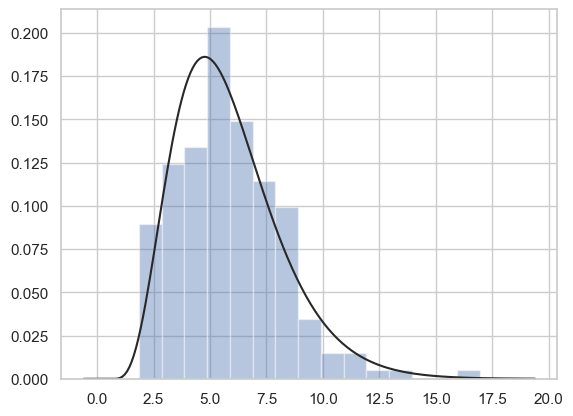

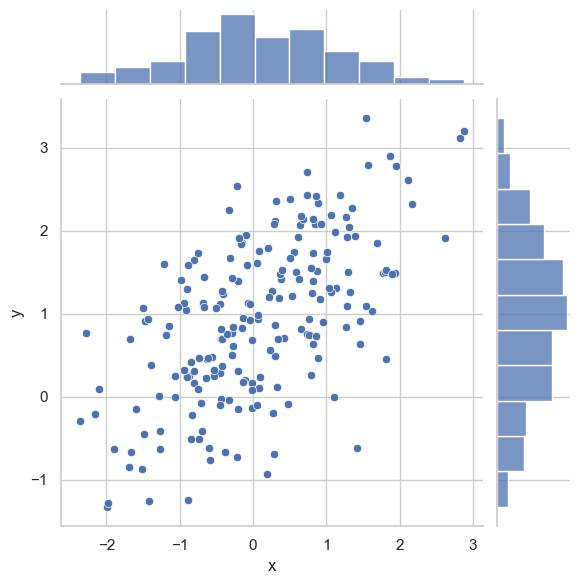

In [18]:
import scipy.stats as stats

# 1. 生成 Gamma 分佈數據並繪圖

# 生成參數為 6 (shape)，樣本數為 200 的 Gamma 分佈隨機數

x = np.random.gamma(6, size=200)

# 繪製直方圖，不顯示 KDE 曲線，但擬合 Gamma 分佈曲線

sns.distplot(x, kde=False, fit=stats.gamma)

# 2. 生成二元正態分佈數據

# 設定平均值 (mean) 與 協方差矩陣

mean, cov = [0, 1], [(1, .5), (.5, 1)]

# 生成 200 筆二元正態隨機數據

data = np.random.multivariate_normal(mean, cov, 200)

# 將數據轉換為 Pandas DataFrame，欄位命名為 'x' 與 'y'

df = pd.DataFrame(data, columns=['x', 'y'])

# 繪製聯合分佈圖 (Joint Plot)，觀察 x 與 y 的相關性

sns.jointplot(x='x', y='y', data=df)

# #seaborn回歸分析繪圖（regplot）

In [19]:
#導入依賴包 
%matplotlib inline 
import numpy as np 
import pandas as pd 
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import seaborn as sns 
#加載sns內置數據集 
tips = sns.load_dataset("tips")

sns.set(color_codes=True)

tips.head(3)
 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


內建數據集-tips數據集 
> 關於數據集，total_bill是消費總金額，tip是小費，size指用餐人數。

<Axes: xlabel='total_bill', ylabel='tip'>

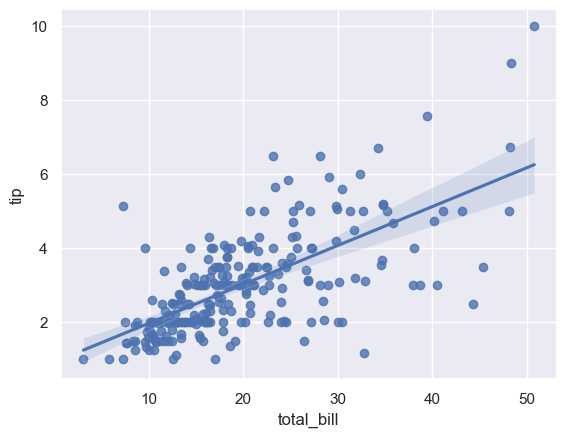

In [20]:
sns.regplot(data=tips, x='total_bill', y='tip')

# [練習]看看其他變量和小費之間的關係。


<Axes: xlabel='size', ylabel='tip'>

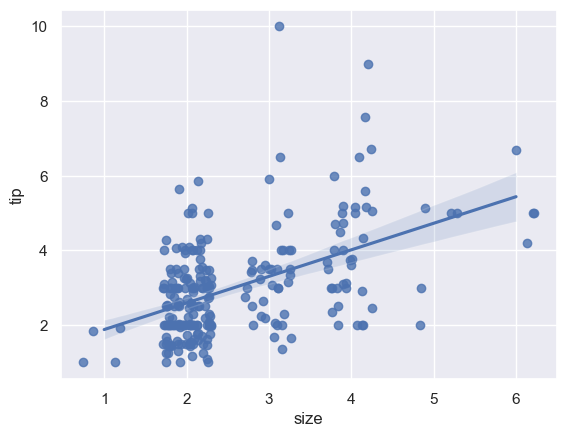

In [22]:
sns.regplot(data=tips, x='size', y='tip',x_jitter=0.3)

<AxesSubplot:xlabel='size', ylabel='tip'>

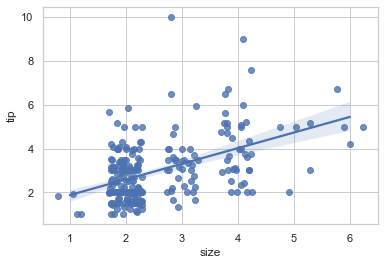

In [21]:
sns.lmplot(x='size', y='tip', col='time', hue='sex', data=tips)

In [23]:
#導入依賴包 %matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set(style="whitegrid", color_codes=True) 
tips = sns.load_dataset("tips")


<Axes: xlabel='tip', ylabel='Density'>

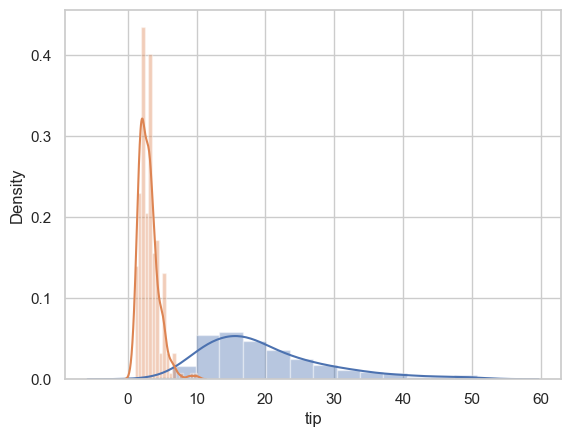

In [24]:
# 繪製總帳單的分佈圖

sns.distplot(tips['total_bill'])

 

# 繪製小費金額的分佈圖

sns.distplot(tips['tip'])

# #散點圖（分布散點、分簇散點圖）

<Axes: xlabel='total_bill', ylabel='tip'>

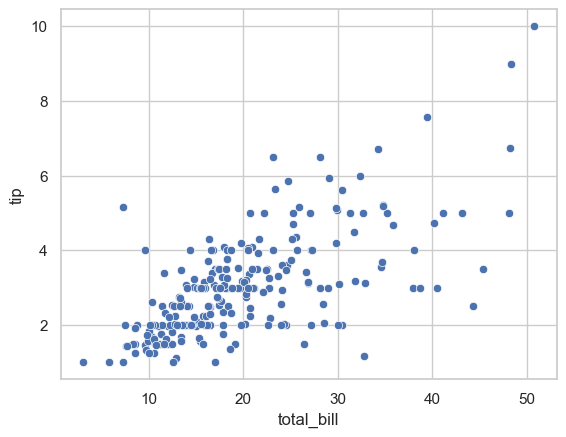

In [25]:
sns.scatterplot(x='total_bill', y='tip', data=tips)

<Axes: xlabel='total_bill', ylabel='tip'>

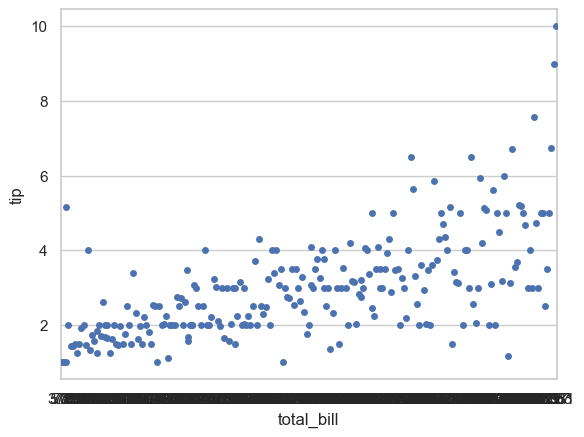

In [26]:
sns.stripplot(x='total_bill', y='tip', data=tips)

從上面的圖中可以看到，stripplot參數中的x是橫軸數據（分類數據），y是縱軸數據（類型對應數據），由於我們將總金額作為分類，導致分類太多，橫軸數據根本看不清，所以我們重新傳參，分別看下性別和小費、時間和小費，用餐日期跟小費之間的數據分布。

<AxesSubplot:xlabel='sex', ylabel='tip'>

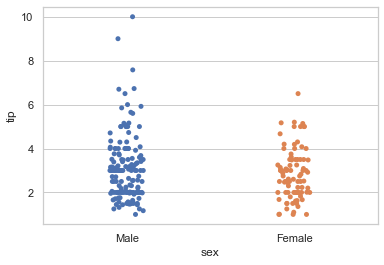

<Axes: xlabel='sex', ylabel='tip'>

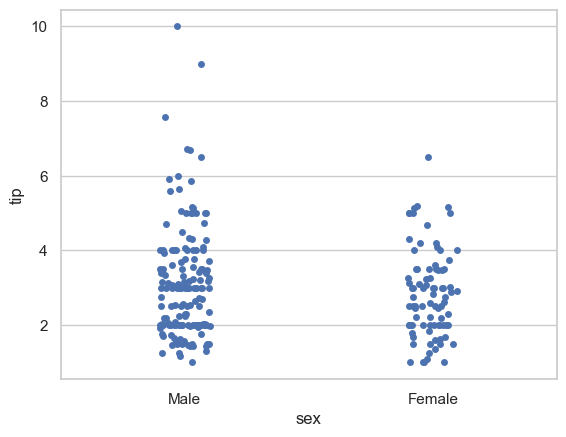

In [27]:
# 1. 觀察性別 (sex) 與小費 (tip) 的關係

sns.stripplot(x='sex', y='tip', data=tips)

<Axes: xlabel='day', ylabel='tip'>

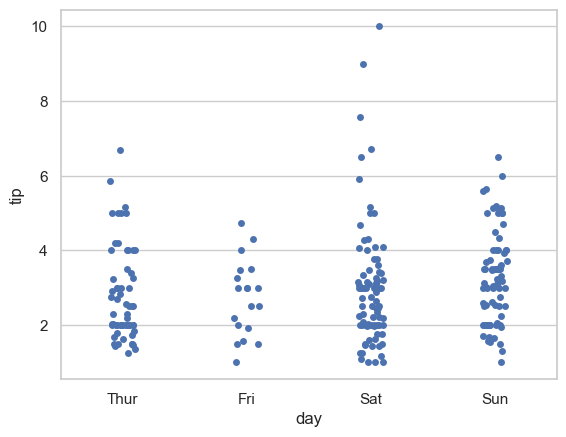

In [28]:
# 2. 練習：觀察星期 (day) 與小費 (tip) 的關係

sns.stripplot(x='day', y='tip', data=tips)

<Axes: xlabel='time', ylabel='tip'>

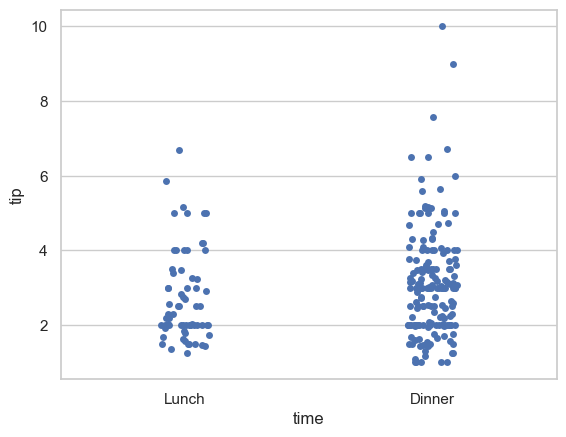

In [29]:
# 3. 練習：觀察時段 (time) 與小費 (tip) 的關係

sns.stripplot(x='time', y='tip', data=tips)

 

因為jitter（數據抖動）這個參數的默認值是True,如果我們將其設置為False，效果如圖：


<Axes: xlabel='day', ylabel='tip'>

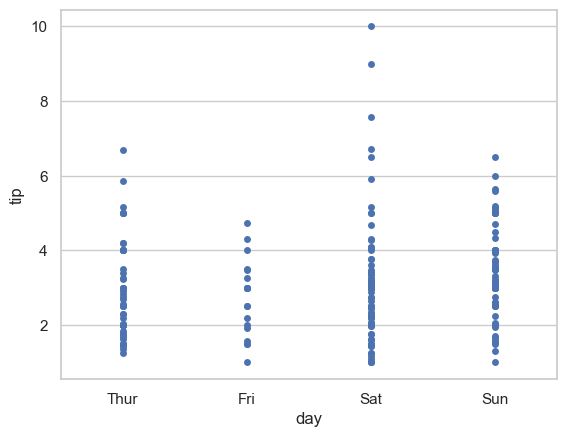

In [30]:
sns.stripplot(x='day', y='tip', jitter=False, data=tips)

<Axes: xlabel='day', ylabel='tip'>

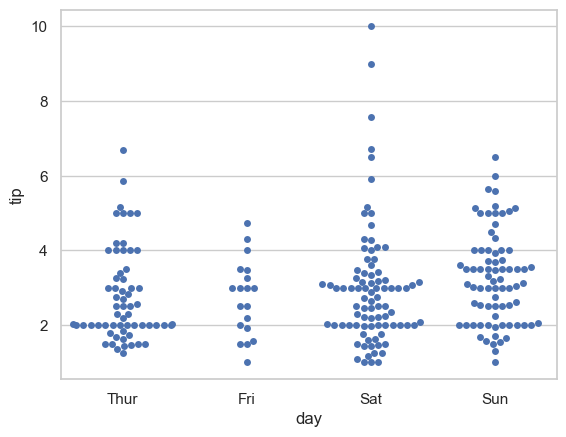

In [31]:
sns.swarmplot(x="day", y="tip", data=tips)

在stripplot函數中，我們只看了某一類別對應的數據，而沒有看類中對應其他類的數據分布，舉個例子，比如我們用stripplot看到男性和女性對應的小費數據，但是不知道男性和女性對應的數據中哪些是吸菸的，哪些是不吸菸的，對於這個問題這兩個函數都有一個hue參數，這裡我們就以分簇散點圖函數為例，演示下這個參數的效果，如圖：


<Axes: xlabel='day', ylabel='tip'>

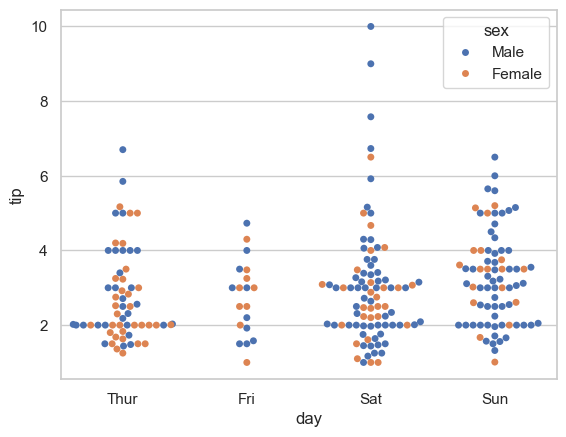

In [32]:
sns.swarmplot(x="day", y="tip", hue="sex", data=tips)

上面這個圖就很好的展示了不同性別在不同的星期中付小費數據的分布。

# #繪製盒圖、小提琴圖
seaborn.boxplot()
這個函數主要是繪製出一個箱型圖來反映離群點數據。

<Axes: xlabel='tip'>

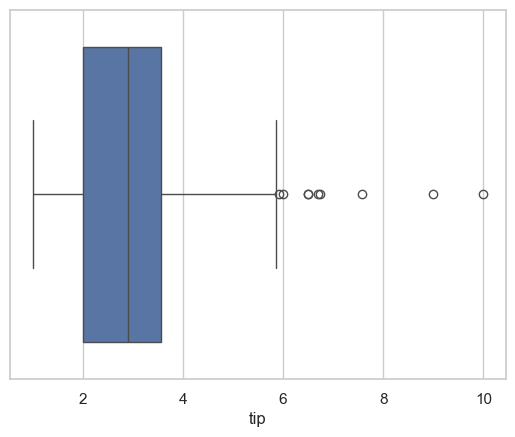

In [33]:
# 1. 橫向箱型圖：觀察小費分佈

sns.boxplot(x='tip', data=tips)

<Axes: ylabel='tip'>

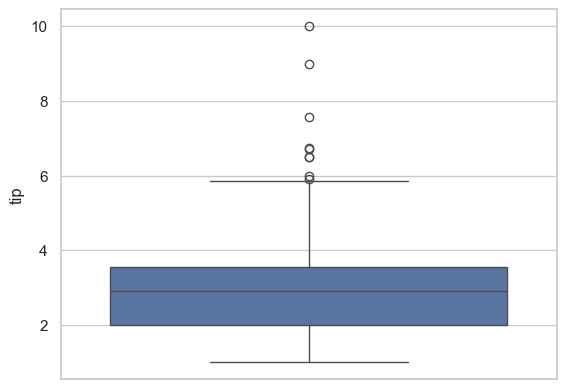

In [34]:
# 2. 縱向箱型圖

sns.boxplot(y='tip', data=tips)

<Axes: xlabel='day', ylabel='tip'>

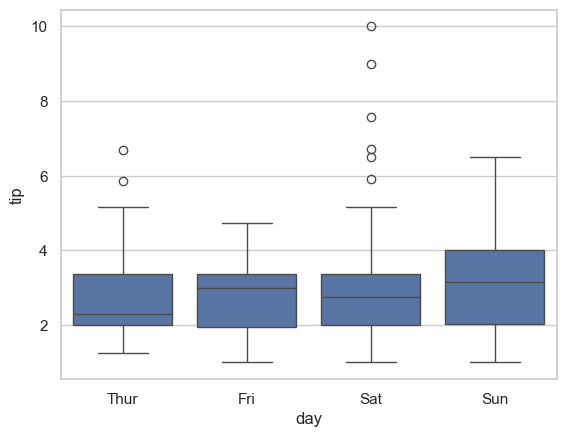

In [35]:
# 3. 分組箱型圖：按星期 (day) 查看小費分佈

sns.boxplot(x='day', y='tip', data=tips)

seaborn庫中的很多繪圖方法就是提前給你畫好模板，我們只需要把數據傳進去就得到相應的圖形，
基於此，我門是不是可以在同一個模板上同時繪製分簇圖和箱型圖呢？

<Axes: xlabel='day', ylabel='total_bill'>

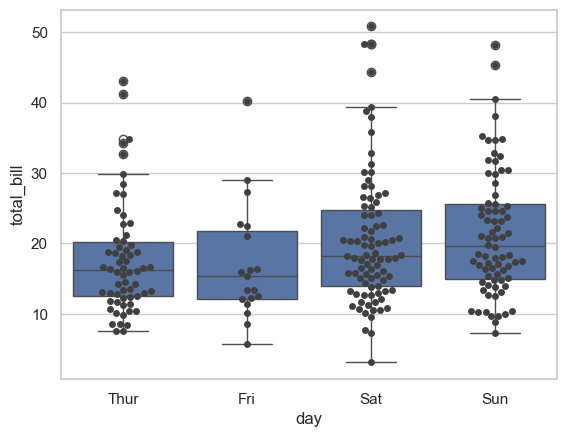

In [36]:
# 先畫底層的箱型圖

sns.boxplot(x='day', y='total_bill', data=tips)

# 再把數據點疊上去，顏色設為黑色 (c='0.25') 以便區分

sns.swarmplot(x='day', y='total_bill', data=tips, color='0.25')

<Axes: xlabel='day', ylabel='tip'>

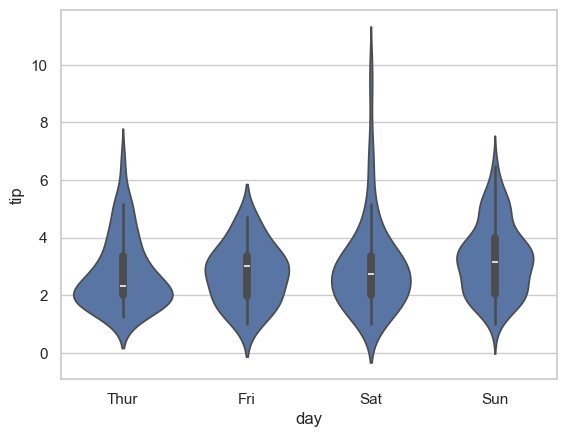

In [37]:
sns.violinplot(y='tip', x='day', data=tips)

小提琴圖即反映了數據的離群情況，同時也反映了數據的分布密度。<br>
此函數跟箱型圖一樣，也有hue參數，可以查看第二個分類屬性下的數據分布，如下：


<Axes: xlabel='day', ylabel='tip'>

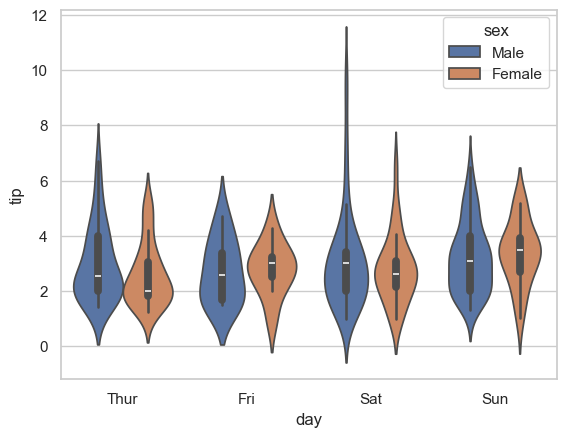

In [38]:
sns.violinplot(y='tip', x='day', hue='sex', data=tips)

可以看到，上面的小提琴圖是4對8個，即當設置hue參數為sex時，每個小提琴的數據集是一類數據，那有沒有辦法讓男性對應數據和女性對應數據都作為一個數據集繪製出一個小提琴圖，只是在一個圖中區分男性數據和女性數據呢？答案是肯定的，violinplot()函數提供了一個split參數，可以做到以上需求，如下：


<Axes: xlabel='day', ylabel='tip'>

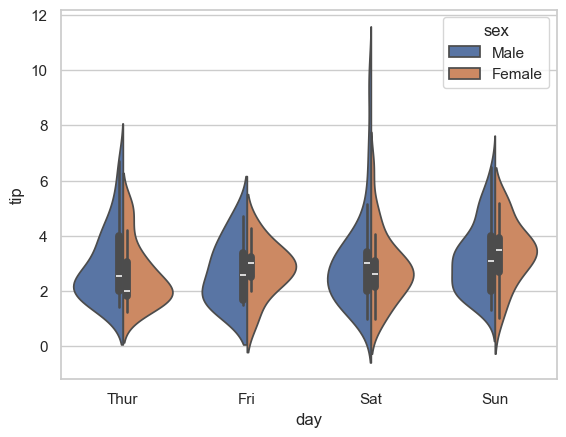

In [39]:
sns.violinplot(y='tip', x='day', hue='sex', data=tips, split=True)

除此以外，我們再來看一下inner參數，上面的小提琴圖中內部都是箱型圖，通過inner參數，我們可以設置其他類型，inner可選參數有：box、quartile(四分位)、point、stick。我們依次看下：


<Axes: xlabel='day', ylabel='tip'>

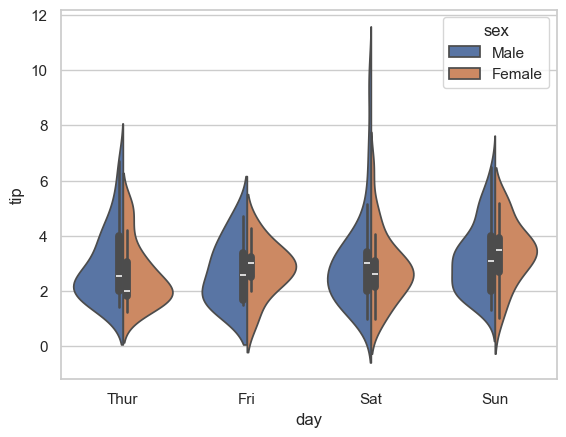

In [40]:
sns.violinplot(y='tip', x='day', hue='sex', data=tips, split=True, inner="box")

<Axes: xlabel='day', ylabel='tip'>

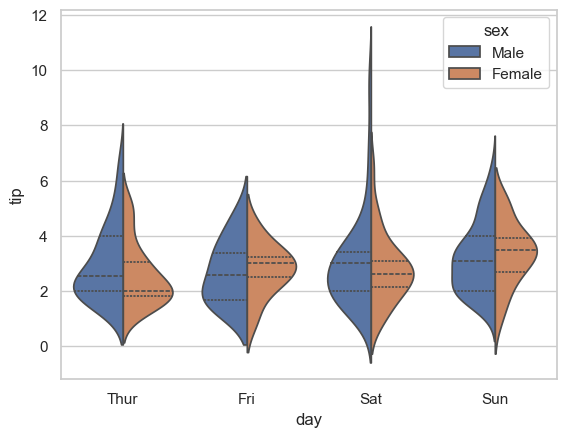

In [41]:
sns.violinplot(y='tip', x='day', hue='sex', data=tips, split=True, inner="quartile")

<Axes: xlabel='day', ylabel='tip'>

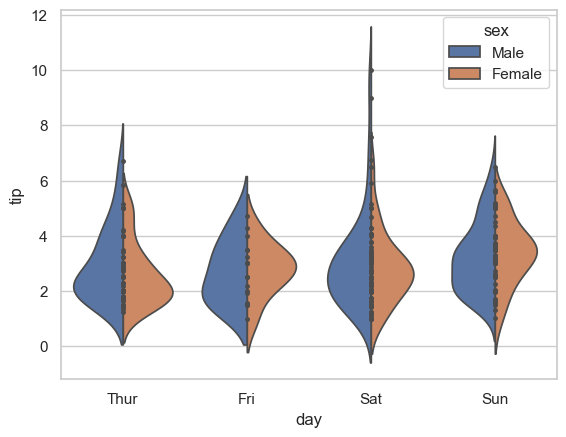

In [42]:
sns.violinplot(y='tip', x='day', hue='sex', data=tips, split=True, inner="point")

<Axes: xlabel='day', ylabel='tip'>

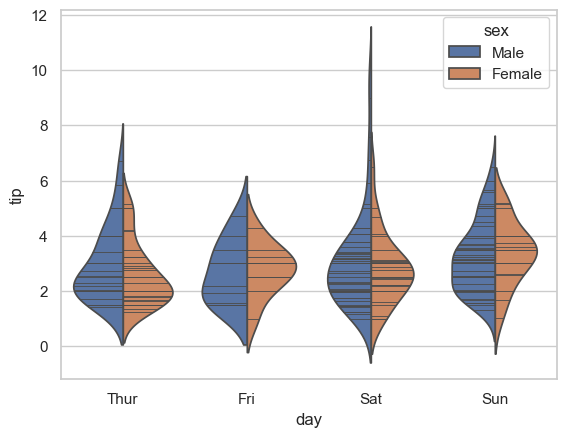

In [43]:
sns.violinplot(y='tip', x='day', hue='sex', data=tips, split=True, inner="stick")

# #結構化展示多維數據
***Visualizing the multidimensional relationships among the samples is as easy as calling sns.pairplot:***

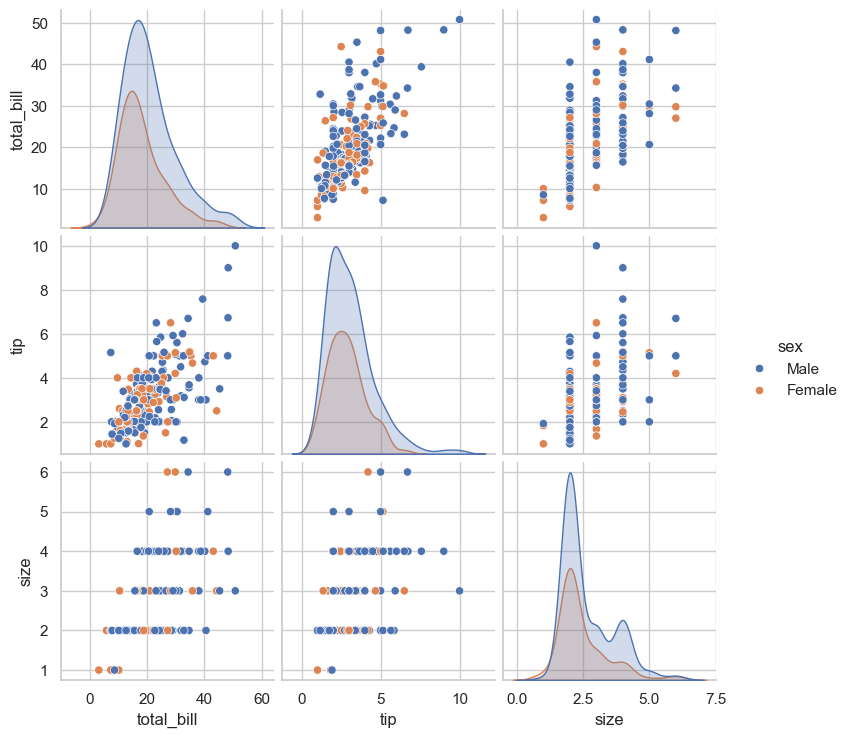

In [45]:
# 1. 配對圖：一次看清所有數值欄位兩兩之間的關係

# hue='sex' 會根據性別上色，height=2.5 控制每個小圖的大小

sns.pairplot(tips, hue='sex', height=2.5)

 



使用FacetGrid時，我們會通過一個pandas DataFrame以及控制圖形網格的行、列和顏色的變量名稱來初始化一個對象。這些維度變量（控制行、列和顏色的變量）應該是分類變量或者離散變量，然後這些變量的不同水平組合起來就構成了整個圖形的每一個子圖（facet，在這裡可以理解為我們維度拆解的最小粒度）


這一函數的目標是一步到位地提供一幅完整的成品圖，它在完成繪圖後還會對每個坐標軸添加注釋。

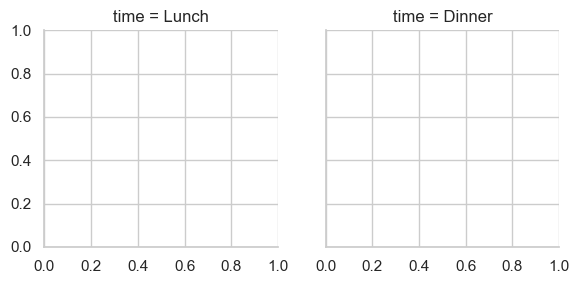

In [46]:
g = sns.FacetGrid(tips, col="time")

In [47]:
g.map(plt.hist, "tip")

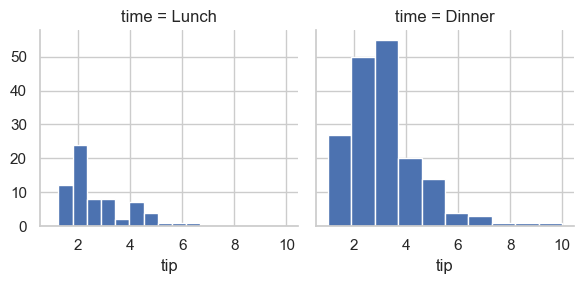

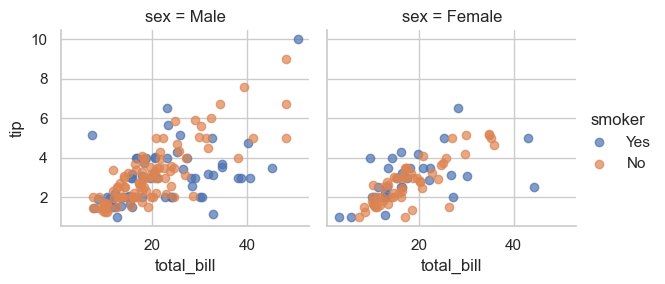

In [48]:
g = sns.FacetGrid(tips, col="sex", hue="smoker")

g.map(plt.scatter, "total_bill", "tip", alpha=.7)

g.add_legend()

我們可以指定某個seaborn調色板，也可以通過字典將hue變量中的每個分類與其對應的matplotlib顏色傳遞給函數<br>
（這樣就可以隨心所以使用大量的matplotlib支持的色彩）


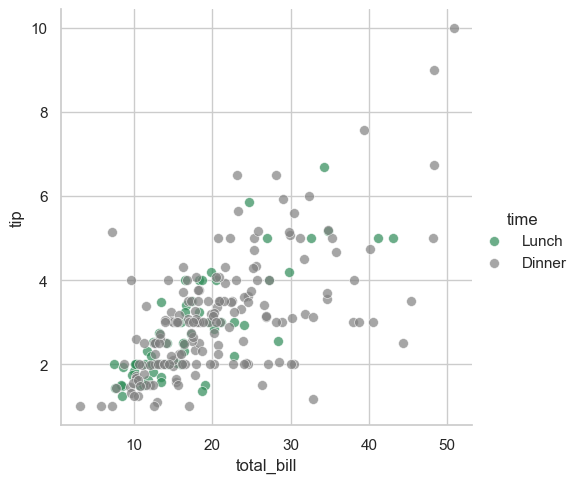

In [50]:
# 1. 定義顏色字典，手動指定類別對應的顏色

pal = dict(Lunch="seagreen", Dinner="gray")

 

# 2. 建立分面網格物件

# hue='time' 代表根據時段上色，palette=pal 套用我們自訂的顏色

g = sns.FacetGrid(tips, hue='time', palette=pal, height=5)

 

# 3. 在網格中繪製散佈圖

# s=50: 點的大小

# alpha=.7: 透明度

# linewidth=.5: 標記外框粗細

# edgecolor='white': 標記外框顏色 (白色外框能讓重疊的點更清晰)

g.map(plt.scatter, "total_bill", "tip", s=50, alpha=.7, linewidth=.5, edgecolor='white')

g.add_legend()


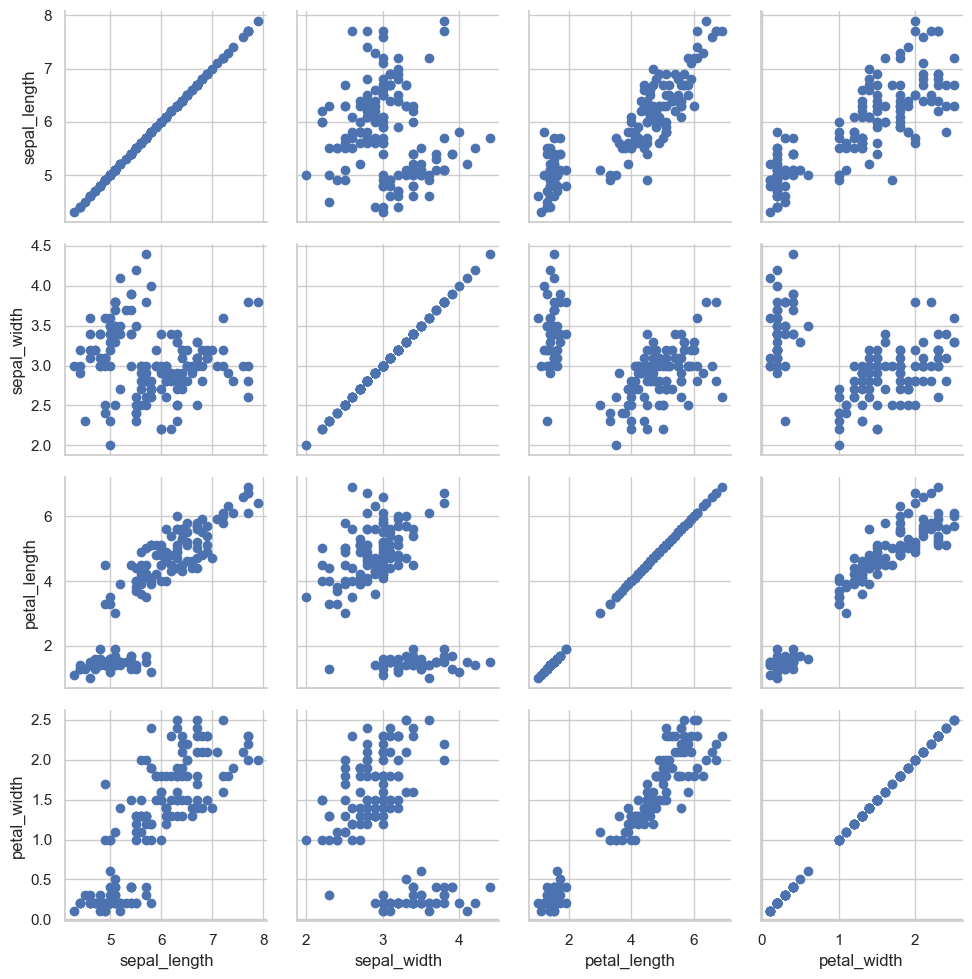

In [51]:
# 1. 加載內置的 tips 數據集

tips = sns.load_dataset('iris')

 

# 2. 建立配對網格 (PairGrid)

# 這會根據數據集中的所有數值欄位（total_bill, tip, size）建立一個 3x3 的矩陣網格

g = sns.PairGrid(tips)

 

# 3. 在所有網格中映射散佈圖

# 這會在矩陣的每一格（包括對角線）都畫上散佈圖

g.map(plt.scatter);

map_diag()函數是繪製對角線上的單變量子圖，mag_offdiag是繪製對角線以外的兩個變量間的子圖。

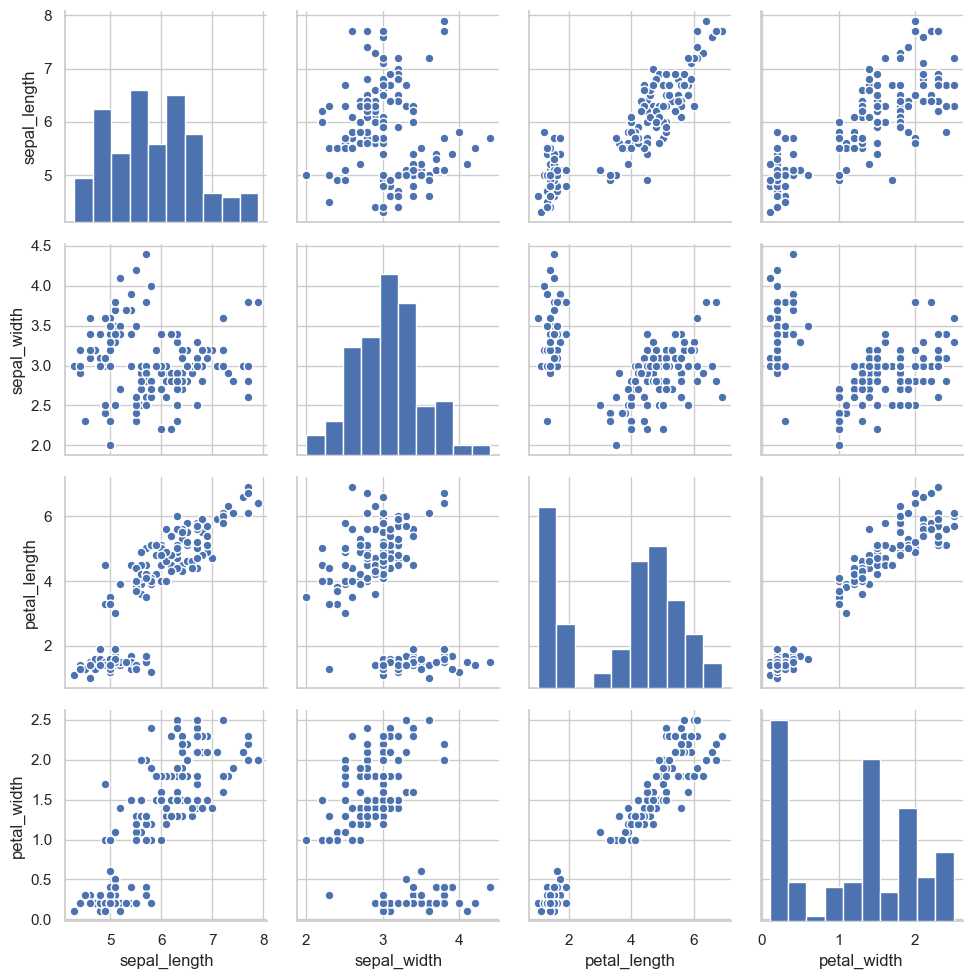

In [52]:
# 1. 建立配對網格框架

g = sns.PairGrid(tips)

 

# 2. 在對角線 (Diagonal) 繪製直方圖

# edgecolor='w' 代表設定白色外框，讓長條圖之間有間隔感

g = g.map_diag(plt.hist, edgecolor='w')

 

# 3. 在非對角線 (Off-diagonal) 繪製散佈圖

# s=40 代表點的大小，edgecolor='w' 則幫散佈點加上白色外框，增加辨識度

g = g.map_offdiag(plt.scatter, edgecolor='w', s=40)

# [練習]試著讀取自己的資料，繪製出多維數據圖表

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


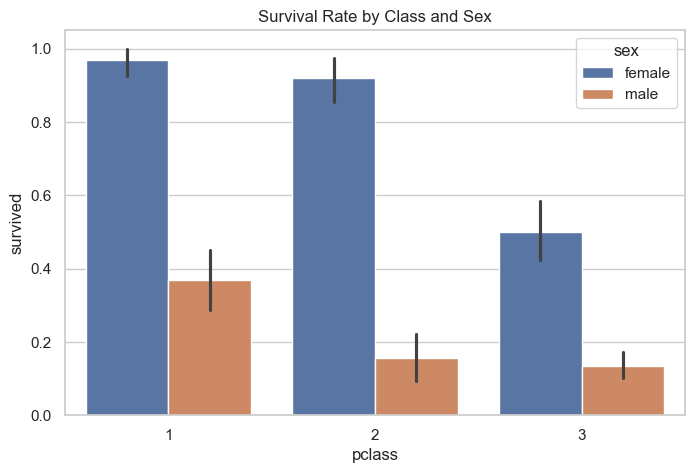

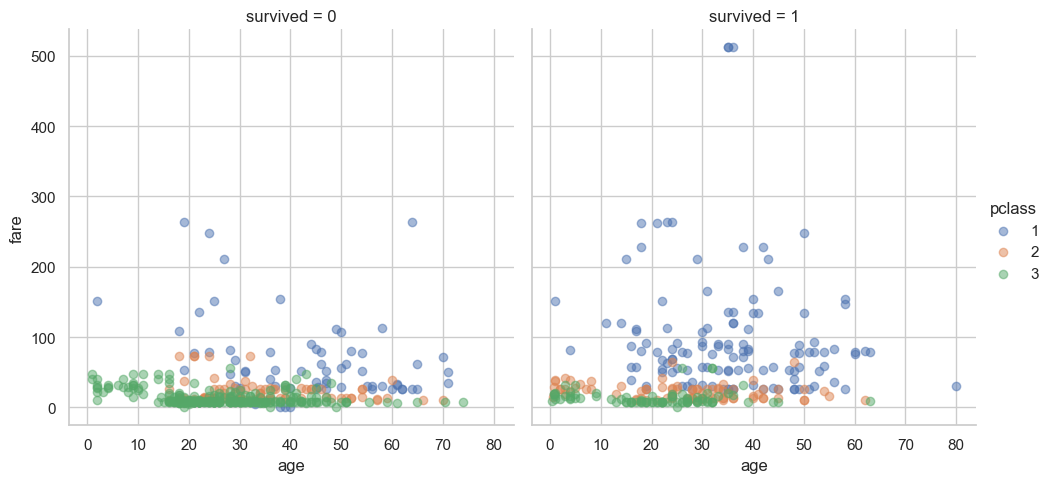

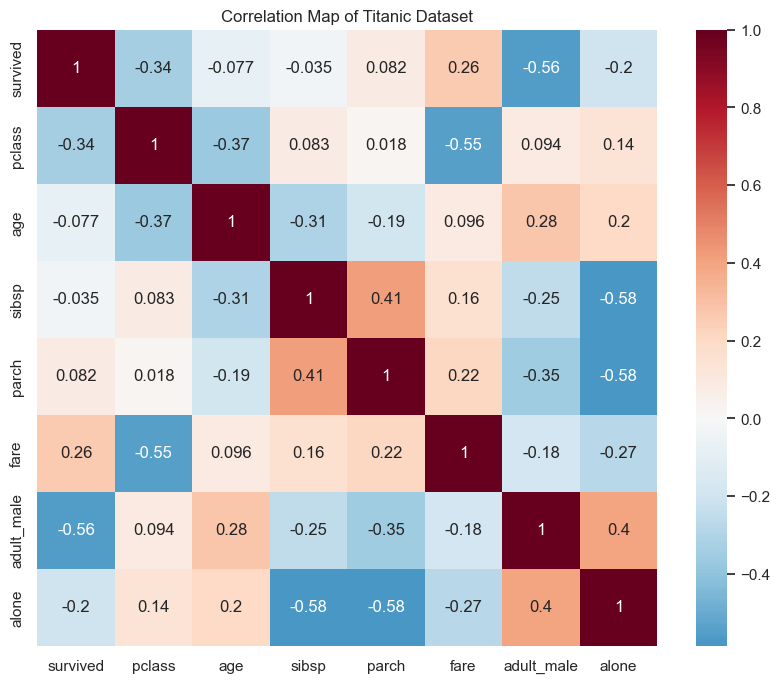

In [53]:
import seaborn as sns

import matplotlib.pyplot as plt

import pandas as pd

 

# 1. 載入數據集

titanic = sns.load_dataset('titanic')

 

# 2. 查看前 5 筆資料，了解欄位

# survived: 是否生存 (0=否, 1=是), pclass: 艙等 (1, 2, 3), fare: 票價

print(titanic.head())

 

plt.figure(figsize=(8, 5))

# x 軸是艙等，y 軸是生存率，hue 用顏色區分性別

sns.barplot(x="pclass", y="survived", hue="sex", data=titanic)

plt.title("Survival Rate by Class and Sex")

plt.show()

 

# 根據是否生存 (survived) 分成兩欄，根據艙等 (pclass) 分顏色

g = sns.FacetGrid(titanic, col="survived", hue="pclass", height=5)

g.map(plt.scatter, "age", "fare", alpha=0.5)

g.add_legend()

plt.show()

 

plt.figure(figsize=(10, 8))

# 計算相關係數矩陣，只考慮數值型別的欄位

corr = titanic.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)

plt.title("Correlation Map of Titanic Dataset")

plt.show()